In [4]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


inspection_id = "0AGBXB4WEGN" #fhr11
angle_profiles = ["0"]
workflow_name = "dent_detection_ae"
num_tracks = 22
run_number = 10
environment = "prod" 

In [5]:
def download_s3_folder(bucket_name: str, s3_folder: str, local_dir: str = None):
    """
    Download the contents of a folder directory
    Args:
        bucket_name: the name of the s3 bucket
        s3_folder: the folder path in the s3 bucket
        local_dir: the dir data is downloaded to
    """
    s3 = boto3.resource("s3")
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=s3_folder):
        target = (
            obj.key
            if local_dir is None
            else os.path.join(local_dir, os.path.relpath(obj.key, s3_folder))
        )
        if not os.path.exists(os.path.dirname(target)):
            os.makedirs(os.path.dirname(target))
        if obj.key[-1] == "/":
            continue
        if not os.path.exists(target):
            bucket.download_file(obj.key, target)
            print("Downloading: {}".format(obj.key))

results_dir = f"/mnt/f/data-files/{inspection_id}/{workflow_name}"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
download_s3_folder("dv-ilit0011", f"track_runs/{inspection_id}/{workflow_name}/", results_dir)

In [6]:
root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))

In [7]:
len(data_files), data_files

(784,
 [PosixPath('/mnt/f/data-files/0AGBXB4WEGN/dent_detection_ae/distance_0000000250.0_0000000500.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AGBXB4WEGN/dent_detection_ae/distance_0000000500.0_0000000750.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AGBXB4WEGN/dent_detection_ae/distance_0000000750.0_0000001000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AGBXB4WEGN/dent_detection_ae/distance_0000001000.0_0000001250.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AGBXB4WEGN/dent_detection_ae/distance_0000001250.0_0000001500.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AGBXB4WEGN/dent_detection_ae/distance_0000001500.0_0000001750.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AGBXB4WEGN/dent_detection_ae/distance_0000001750.0_0000002000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AGBXB4WEGN

In [8]:

import ast
# Function to parse probability strings into actual lists if needed
def parse_prob(prob_str):
    """Convert string representation of list to actual list if needed"""
    if isinstance(prob_str, str):
        try:
            return ast.literal_eval(prob_str)
        except:
            return []
    return prob_str

## Create a DataFrame for each profile and track and range
def create_df(frame_range=None):
    if frame_range is None:
        data_files_range = [f for f in data_files]
    else:
        data_files_range = [f for f in data_files if f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]

    def read_and_validate(path):
        df = pd.read_csv(path)
        if df.empty:
            return df
        df['prob'] = df['prob'].apply(parse_prob)
        df = df[df['prob'].apply(lambda probs: any(p > 0.05 for p in probs))] 
        
        
        # max probability over all tracks other than tracks 20 and 21 (0-based index)
        EXCLUDE_TRACK_INDICES = {20, 21}
        def max_prob_excluding_track(probs, exclude_indices=EXCLUDE_TRACK_INDICES):
            if not probs:
                return 0, -1
            valid = [(p, i) for i, p in enumerate(probs) if i not in exclude_indices]
            if not valid:
                return 0, -1
            max_p, max_i = max(valid, key=lambda x: x[0])
            return max_p, max_i
        df['max_prob'] = df['prob'].apply(lambda probs: max_prob_excluding_track(probs)[0])
        df['max_prob_track'] = df['prob'].apply(lambda probs: max_prob_excluding_track(probs)[1])
        return df
    
    dfs = [df for df in (read_and_validate(path) for path in data_files_range) if not df.empty]

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

In [9]:
all_dfs = create_df()
display(all_dfs)

,start,end,prob,max_prob,max_prob_track
47,256.900000,257.200000,"[0.0, 0.0, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0, 0....",0.6896,10
50,257.350000,257.650000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.1330,19
57,258.400000,258.700000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.1469,18
69,260.200000,260.500000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0005, 0.822, 0.0, ...",0.8220,6
70,260.350000,260.650000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.8486, 0.9996, 0.00...",0.9996,6
...,...,...,...,...,...
1550,235.220602,235.520602,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0115,19
1569,238.070602,238.370602,"[0.0147, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.6875,19
1606,243.620602,243.920602,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0000,0
1611,244.370602,244.670602,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0001,19


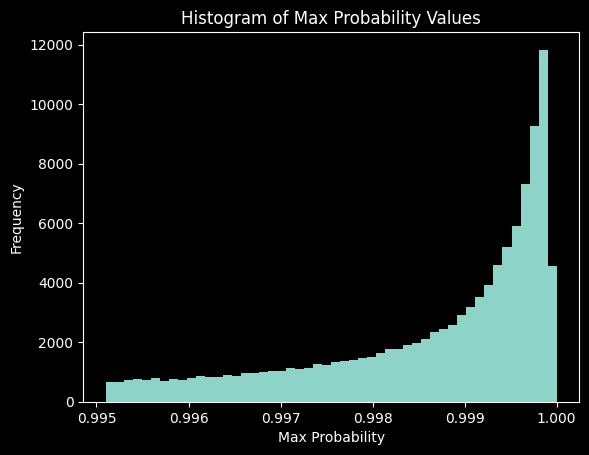

In [10]:
#make a histogram of all max_prob values
plt.style.use('dark_background')
plt.hist(all_dfs[all_dfs['max_prob']>0.995]['max_prob'], bins=50)
plt.xlabel('Max Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Max Probability Values')
plt.show() 

Text(0.5, 1.0, 'Histogram of Max Probability Track Indices')

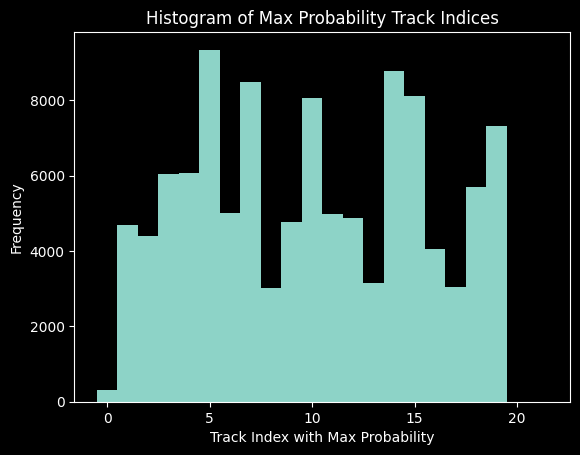

In [11]:
#make the histogram of max_prob_index values
plt.hist(all_dfs[all_dfs['max_prob']>0.995]['max_prob_track'], bins=num_tracks, range=(-0.5, num_tracks-0.5), align='mid')
plt.xlabel('Track Index with Max Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Max Probability Track Indices')

Filtered DF size: 20306


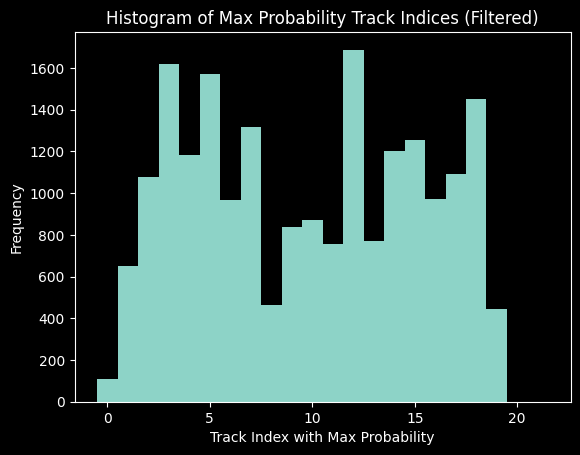

In [12]:
# Filter: keep if >=2 tracks have prob > th1, or exactly 1 track has prob > th2
multi_track_th1, multi_track_th2, single_track_th = 0.9, 0.999, 1
def keep_row_by_probs(probs):
    if not probs:
        return False
    n_multi_tracks = sum(1 for p in probs[0:20] if p > multi_track_th1)
    n_multi_tracks_th2 = sum(1 for p in probs[0:20] if p > multi_track_th2)
    n_single_track = sum(1 for p in probs[0:20] if p > single_track_th)
    if n_multi_tracks >= 3:
        return True
    if n_multi_tracks_th2 >= 2:
        return True
    if n_single_track == 1:
        return True
    return False
filtered_df = all_dfs[all_dfs['prob'].apply(keep_row_by_probs)].copy()
print(f"Filtered DF size: {len(filtered_df)}")
plt.hist(filtered_df['max_prob_track'], bins=num_tracks, range=(-0.5, num_tracks-0.5), align='mid')
plt.xlabel('Track Index with Max Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Max Probability Track Indices (Filtered)')
plt.show()

In [13]:
import numpy as np

def filter_close_detections(df, distance_threshold=0.2):
    """
    Filter out detections that are close to each other.
    When multiple detections are within distance_threshold, keep only the one with highest max_prob.
    
    Args:
        df: DataFrame with 'start' and 'max_prob' columns
        distance_threshold: Maximum allowed distance between starts (default 0.2)
        
    Returns:
        DataFrame with filtered rows
    """
    if len(df) <= 1:
        return df
    
    # Sort by start descending
    df_sorted = df.sort_values(by='start', ascending=False).reset_index(drop=True)
    
    # Group detections within threshold
    starts = df_sorted['start'].values
    probs = df_sorted['max_prob'].values
    
    groups = []
    current_group = [0]
    
    for i in range(1, len(df_sorted)):
        # Check if within threshold of the first item in current group
        if starts[current_group[0]] - starts[i] < distance_threshold:
            current_group.append(i)
        else:
            # Finalize current group, keep highest prob
            groups.append(current_group)
            current_group = [i]
    
    # Don't forget the last group
    groups.append(current_group)
    
    # For each group, keep only the one with max prob
    kept_indices = []
    for group in groups:
        max_prob_idx = group[np.argmax(probs[group])]
        kept_indices.append(max_prob_idx)
    
    return df_sorted.iloc[kept_indices].reset_index(drop=True)

final_df = filter_close_detections(filtered_df)
print(f"Original df: {len(filtered_df)} rows")
print(f"final df: {len(final_df)} rows")

Original df: 20306 rows
final df: 17683 rows


In [14]:
#save final_df
final_df.to_parquet(f"./insp_{inspection_id}_final_df_ae.parquet", index=False)
display(final_df)

,start,end,prob,max_prob,max_prob_track
0,195900.600000,195900.900000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9985,14
1,195896.250000,195896.550000,"[0.0, 0.0, 0.0004, 0.0732, 0.9179, 0.9931, 0.9...",0.9931,5
2,195894.900000,195895.200000,"[0.0001, 0.0002, 0.0067, 0.5627, 0.9148, 0.992...",0.9929,5
3,195888.600000,195888.900000,"[0.0, 0.0, 0.0, 0.0, 0.0035, 0.9952, 0.9996, 0...",0.9996,6
4,195877.950000,195878.250000,"[0.0, 0.0, 0.0, 0.0002, 0.9997, 0.9995, 0.0, 0...",0.9997,4
...,...,...,...,...,...
17678,14.420602,14.720602,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9998,14
17679,12.170602,12.470602,"[0.0, 0.0, 0.0002, 0.99, 0.9969, 0.9095, 0.000...",0.9969,4
17680,10.670602,10.970602,"[0.0041, 0.914, 0.9702, 0.9994, 0.9661, 0.6842...",0.9994,3
17681,10.370602,10.670602,"[0.0003, 0.0153, 0.2083, 0.9614, 0.9808, 0.930...",0.9808,4


In [15]:
import sys
import os

# Add parent directory to path (adjust as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added {project_root} to Python path")
    
from rnd.utils.data_utils import (
    extract_arm_angles,
    create_arm_array,
)
from ilipy import Session
from ilipy.database import DistanceCorrelation

root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)

session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

def gen_image(img_start, session, dist_corr, length= 0.3, show_im=True, normalize="std"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=num_tracks,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.colorbar()
        plt.show()
    return img


Added /home/zmirikha/Github/rnd_q2 to Python path
Loading stub library for: libnppial.so.11
Loading stub library for: libnppig.so.11
Loading stub library for: libnppist.so.11
Loading stub library for: libnppc.so.11
PySettings.cpp(46): ilipy: Build 1.1.0.13962 c753373574 release-ili-1.1 'Wed Mar  4 17:58:39 2026'

PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.

CognitoAuthenticator.cpp(158): Using Cognito Credentials

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

DatabaseWebSocket.cpp(153): WebSocket connection established to https://backend.ili-prod.da

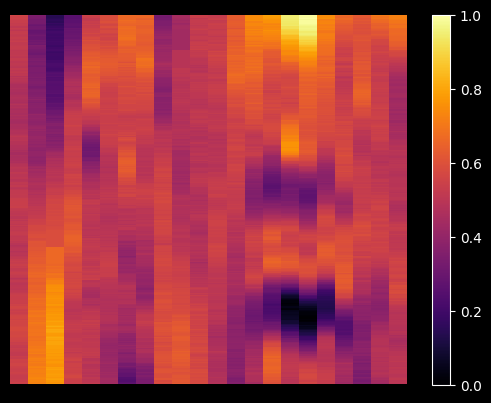

195900.74999999412 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0007, 0.4979, 0.9985, 0.9899, 0.963, 0.5087, 0.0012, 0.0006, 0.0001, 0.0]
ObserverHost.cpp(207): [ObserverHost] Registering with dv-observer at localhost:8000...

ObserverHost.cpp(212): [ObserverHost] Using listening server address localhost:33619

ObserverHost.cpp(250): [ObserverHost] Failed to register with dv-observer, response code: -1



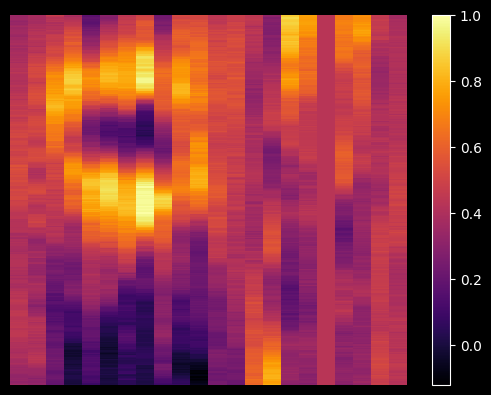

195896.39999999432 [0.0, 0.0, 0.0004, 0.0732, 0.9179, 0.9931, 0.9677, 0.8924, 0.0011, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0]


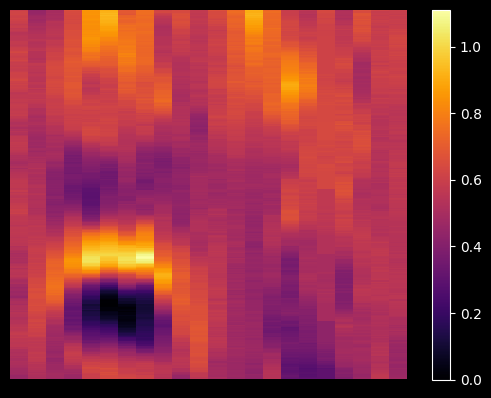

195895.0499999944 [0.0001, 0.0002, 0.0067, 0.5627, 0.9148, 0.9929, 0.9608, 0.8116, 0.0068, 0.0001, 0.0001, 0.0002, 0.0, 0.0001, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0]


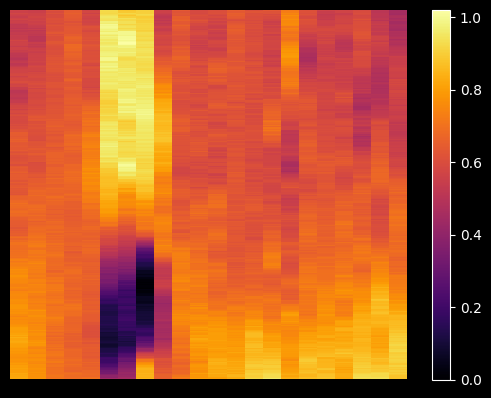

195888.74999999464 [0.0, 0.0, 0.0, 0.0, 0.0035, 0.9952, 0.9996, 0.9994, 0.0041, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


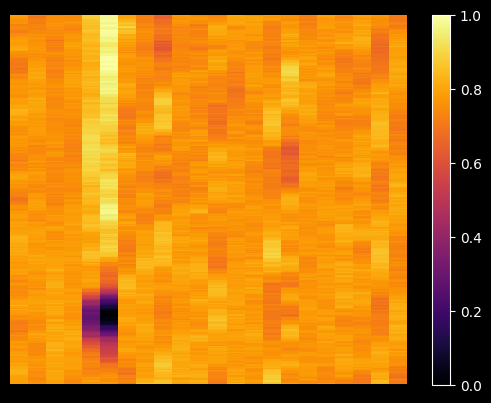

195878.09999999503 [0.0, 0.0, 0.0, 0.0002, 0.9997, 0.9995, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
ObserverHost.cpp(207): [ObserverHost] Registering with dv-observer at localhost:8000...

ObserverHost.cpp(212): [ObserverHost] Using listening server address localhost:33619

ObserverHost.cpp(250): [ObserverHost] Failed to register with dv-observer, response code: -1



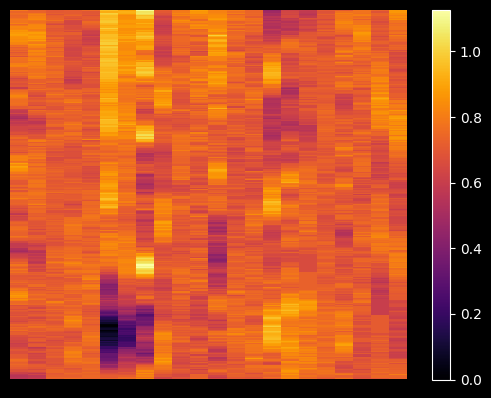

195854.54999999597 [0.0, 0.0, 0.0, 0.0, 0.0015, 0.9998, 0.9999, 0.2344, 0.0004, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


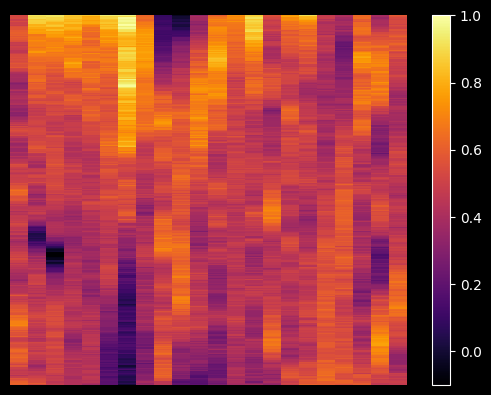

195842.09999999643 [0.0001, 0.9992, 0.9996, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


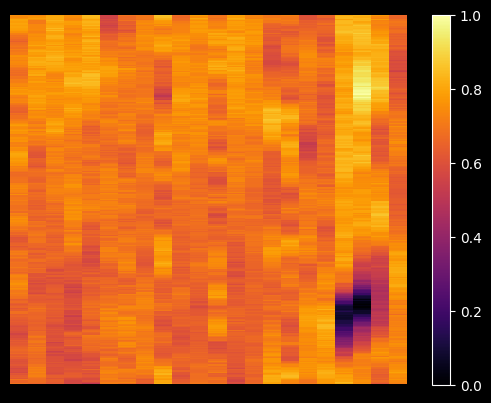

195825.44999999707 [0.0051, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0002, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0017, 0.9998, 0.9994, 0.3367, 0.0001]


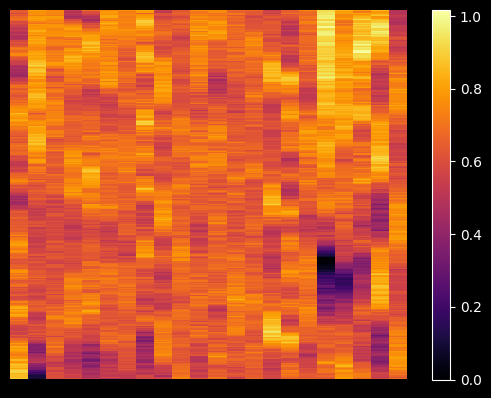

195823.94999999716 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0012, 0.9999, 0.9998, 0.0058, 0.0003, 0.0001]


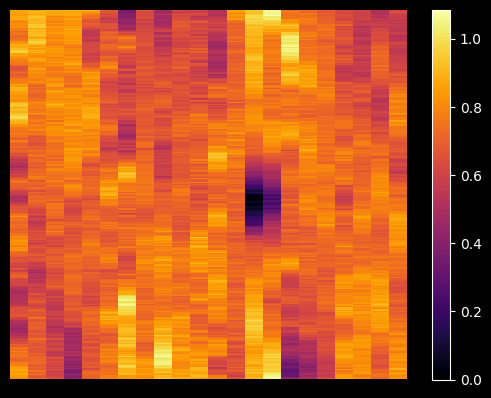

195816.29999999743 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9999, 0.9999, 0.0003, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
ObserverHost.cpp(207): [ObserverHost] Registering with dv-observer at localhost:8000...

ObserverHost.cpp(212): [ObserverHost] Using listening server address localhost:33619

ObserverHost.cpp(250): [ObserverHost] Failed to register with dv-observer, response code: -1



KeyboardInterrupt: 

ObserverHost.cpp(207): [ObserverHost] Registering with dv-observer at localhost:8000...

ObserverHost.cpp(212): [ObserverHost] Using listening server address localhost:33619

ObserverHost.cpp(250): [ObserverHost] Failed to register with dv-observer, response code: -1



In [ ]:
for i, row in final_df.head(50).iterrows():
    vd = (row['start']+ row['end'])/2
    img_std = gen_image(row['start'], session, dist_corr, length=0.3, show_im=True, normalize="std")

    print(vd, row['prob'])

In [17]:
df_us_final= pd.read_parquet("./insp_0AGBXB4WEGN_final_df_us_with_final_track_id.parquet")
display(df_us_final)

,view_distance_group,view_distance_start_count,view_distance_start_min,view_distance_start_max,view_distance_start_mean,track_ids,view_distance_stop_min,view_distance_stop_max,view_distance_stop_mean,avg_confidence_mean,avg_confidence_max,avg_confidence_min,sequence_length_mean,sequence_length_sum,unique_tracks_count,final_track_id
0,3.9,32,3.961223,5.266587,3.988817,"[0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 5, 5, ...",5.162941,6.711904,6.576820,0.991591,0.992775,0.990375,58.016667,228.875,2,5
1,6.9,2,7.019783,7.066533,7.043158,"[7, 17]",7.098553,7.136659,7.117606,0.991800,0.992200,0.991400,42.500000,85.000,2,7
2,9.0,2,9.109379,9.214267,9.161823,"[10, 12]",9.145178,9.287665,9.216422,0.992100,0.993000,0.991200,30.000000,60.000,2,10
3,9.6,1,9.687754,9.687754,9.687754,[10],9.722068,9.722068,9.722068,0.991900,0.991900,0.991900,20.000000,20.000,1,10
4,9.9,3,9.887771,10.119656,9.966431,"[0, 9, 17]",9.926361,10.182485,10.052395,0.992167,0.993400,0.990900,48.333333,145.000,3,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5883,195905.7,3,195905.773832,195905.961529,195905.872965,"[2, 3, 4]",195905.790148,195905.984598,195905.894343,0.990533,0.990600,0.990500,13.333333,40.000,3,3
5884,195906.9,3,195906.994562,195907.115868,195907.001896,"[3, 3, 4]",195907.180672,195907.256067,195907.256067,0.993100,0.993500,0.992700,50.000000,90.000,2,3
5885,195912.6,2,195912.683395,195912.751369,195912.717382,"[3, 4]",195912.699585,195912.904681,195912.802133,0.991650,0.992700,0.990600,47.500000,95.000,2,3
5886,195914.4,2,195914.516729,195914.642359,195914.516729,"[3, 3]",195914.717023,195914.801406,195914.801406,0.993150,0.993150,0.993150,42.500000,42.500,1,3


In [18]:
# Add overlap column: for each row in final_df, total overlap with all intervals in df_us_final
# Overlap of [a,b] and [c,d] = max(0, min(b,d) - max(a,c))
import numpy as np
us_starts = df_us_final['view_distance_start_mean'].values
us_ends = df_us_final['view_distance_stop_mean'].values

def total_overlap_with_us(row):
    s, e = row['start'], row['end']
    return np.maximum(0, np.minimum(e, us_ends) - np.maximum(s, us_starts)).sum()

final_df['overlap_with_us'] = final_df.apply(total_overlap_with_us, axis=1)

In [ ]:
display(final_df)

,start,end,prob,max_prob,max_prob_track,overlap_with_us
0,195900.600000,195900.900000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9985,14,0.240765
1,195896.250000,195896.550000,"[0.0, 0.0, 0.0004, 0.0732, 0.9179, 0.9931, 0.9...",0.9931,5,0.000000
2,195894.900000,195895.200000,"[0.0001, 0.0002, 0.0067, 0.5627, 0.9148, 0.992...",0.9929,5,0.000000
3,195888.600000,195888.900000,"[0.0, 0.0, 0.0, 0.0, 0.0035, 0.9952, 0.9996, 0...",0.9996,6,0.000000
4,195877.950000,195878.250000,"[0.0, 0.0, 0.0, 0.0002, 0.9997, 0.9995, 0.0, 0...",0.9997,4,0.000000
...,...,...,...,...,...,...
17678,14.420602,14.720602,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9998,14,0.300000
17679,12.170602,12.470602,"[0.0, 0.0, 0.0002, 0.99, 0.9969, 0.9095, 0.000...",0.9969,4,0.035742
17680,10.670602,10.970602,"[0.0041, 0.914, 0.9702, 0.9994, 0.9661, 0.6842...",0.9994,3,0.300000
17681,10.370602,10.670602,"[0.0003, 0.0153, 0.2083, 0.9614, 0.9808, 0.930...",0.9808,4,0.039586


In [19]:
#how many rows has overlap_with_us > 0.1
len(final_df[final_df['overlap_with_us'] == 0.0])
final_ae_df = final_df[final_df['overlap_with_us']==0.0]
print(len(final_ae_df))
#how many rows has overlap_with_us > 0.2


16786


## Insert Anomalies

In [20]:
from ilipy import ClipTypes, Session, TrackIndex, ViewDistance
from ilipy.channeldata import ImageProfile
from ilipy.features import Bookmarks
from ilipyutils.ml_features.base import get_ml_models_info_list, AnomalyStatus
from ilipyutils.ml_features.insert import FeatureInsert, GeometryCubeParameters
from ili_custom_data.load_model import ModelDataLoader
from ilipy.database import DistanceCorrelation

session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)
bookmarks_interface = Bookmarks(session=session)
feature_insert = FeatureInsert(session=session, bookmarks_interface=bookmarks_interface)
latest_model = ModelDataLoader.get_latest_model()

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.

CognitoAuthenticator.cpp(158): Using Cognito Credentials

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

RequestPool.cpp(84): [HttpRequestPool] Host: dvv-storage-01.darkvision.local, Port: 8070, Concurrent Connections: 1

RequestPool.cpp(84): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8070, Concurrent Connections: 1

RequestPool.cpp(84): [HttpRequestPool] Host: dvv-storage-02.darkvision.local, Port: 8070, Concurrent Connections: 1

RestApi.cpp(84): ApiService Ping Response (http://dvv-storage-01.darkvision.local:8070) : 200, 11ms

RestApi.cpp(84): ApiService Ping Response (http://dvv-storage-02.darkvision.local:8070) : 200, 15ms

RestApi.cpp(84): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8070) : -1, 226ms

RequestPool.cpp(303): Failed to acquire c

In [21]:
def get_decimal_range(value):
    """
    For a number like 0.56, return (0.5, 0.6)
    For a number like 0.78, return (0.7, 0.8)
    
    Args:
        value (float): A decimal value 
        
    Returns:
        tuple: The lower and upper bounds of the decimal range
    """
    # Get the first decimal place as the lower bound
    lower = int(value * 100) / 100
    # The upper bound is just 0.01 more
    upper = round(lower + 0.01, 2)

    return lower, upper

In [22]:
cube_params = GeometryCubeParameters(
tlbr_cube_angle_rad=(np.deg2rad(-15), np.deg2rad(15)),
tlbr_probe_scan_angle_rad=(np.deg2rad(-15), np.deg2rad(15)),
tlbr_radial_position_mm=(200-(1.9/2), 200+(1.9/2)),
)
model_info = next(
    model
    for model in get_ml_models_info_list()
    if model.model_name == "Dent-Detection-v3"
)
model_info

MLModelInfo(model_name='Dent-Detection-v3', model_id=12, model_score_bound=[0, 1], anomaly_type_name='DentPlain')

In [24]:
#print(max_prob)
def f(x):
    return 10*x - 9
f(max_prob)

NameError: name 'max_prob' is not defined

In [25]:
len(final_df)

17683

In [28]:

for i, row in final_df.iterrows():
        print(f"uploading row {i+1} of {len(final_df)}")
        profile = ImageProfile.ZeroAngle 
        vd_start, vd_end, _ , max_prob, max_prob_track = row['start'], row['end'], row['prob'], row["max_prob"], row["max_prob_track"]

        start_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(max_prob_track), ViewDistance(vd_start)).value
        end_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(max_prob_track), ViewDistance(vd_end)).value
        model_instance = latest_model(
        ml_confidence_score=max_prob,)
        lower_bound, upper_bound = get_decimal_range(f(max_prob))
        extra_tags = {f"threshold_bin-{lower_bound}-{upper_bound}"}
        model_instance = latest_model(
        ml_confidence_score=max_prob,)
        print(extra_tags)


        anomaly_info = feature_insert.insert_ml_pred(
        inspection_id=inspection_id,
        tlbr_track_indices=[max_prob_track,max_prob_track],
        tlbr_odometer_ticks=(start_frame_odo_ticks, end_frame_odo_ticks),
        cube_params=cube_params,
        model_info=model_info,
        anomaly_status=AnomalyStatus.REVIEW_DETECTION,
        image_profile=profile,
        extra_tags=extra_tags,
        ili_custom_data=model_instance
       )




uploading row 1 of 17683
{'threshold_bin-0.98-0.99'}
uploading row 2 of 17683
{'threshold_bin-0.93-0.94'}
uploading row 3 of 17683
{'threshold_bin-0.92-0.93'}
uploading row 4 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 5 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 6 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 7 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 8 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 9 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 10 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 11 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 12 of 17683
{'threshold_bin-0.97-0.98'}
uploading row 13 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 14 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 15 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 16 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 17 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 18 of 17683
{'threshold_bin-0.99-1.0'}
uploading row 19 of 17683
{'threshold_bin-0.99-1.0'

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthentic

In [ ]:
cube_params

In [ ]:
# from ilipy import OdometerTicks, ViewDistance
# from ilipy.channeldata import ImageProfile
# from ilipy.database import DistanceCorrelation
# from ilipy.features import (
#     AnomalyInfo,
#     AnomalyStatusTypeEnum,
#     CorrosionAnomalyProperties,
#     GeometryBoundingCube,
#     GeometryCubePoint,
#     JointInfo,
#     SurfaceLocationType,
# )
# from ilipyutils.configs import FF_DEFAULTS

In [ ]:
# feat_list = [vd_start, vd_end, max_prob, max_prob_track]
# def create_anomaly(
#     feat_list, inspection_id: str #, required_tag: str | None
# ):  
#     start_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(feat_list[3]), ViewDistance(feat_list[0])).value
#     end_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(feat_list[3]), ViewDistance(feat_list[1])).value
       
#     anomaly = AnomalyInfo()
#     anomaly.feature.inspection_id = inspection_id
#     unique_name = "{}_{}_{}".format(
#         feat_list[3],
#         str(start_odo_ticks),
#         str(end_odo_ticks),
#     )
#     anomaly.feature.name = unique_name
#     # if required_tag:
#     #     anomaly.tags = {required_tag}.union(set(sizing_result["wall_location"]))
#     # else:
#     #     anomaly.tags = set(sizing_result["wall_location"])
#     anomaly.feature.anomaly_identification_type_id = 303
#     anomaly.feature.anomaly_status_type_id = 1

#     # circles = xr.DataArray(
#     #     np.stack(
#     #         [
#     #             np.array(sizing_result["circle_z"]),
#     #             np.array(sizing_result["circle_y"]),
#     #             np.array(sizing_result["circle_r"]),
#     #         ],
#     #         axis=1,
#     #     ),
#     #     coords=LogicalCoordinates.odo_ticks(sizing_result["circle_odo_tick"]),
#     #     dims=[LogicalCoordinates.odo_ticks.dim, "results"],
#     # )
#     # populate_anomaly_with_circles(  # need to make frame start index right
#     #     anomaly=anomaly,
#     #     circles=circles,
#     #     start_frame_idx=sizing_result[
#     #         "circle_start_frame"
#     #     ],  # need original start frame index here
#     # )

#     bm_cube = GeometryBoundingCube(
#         image_profile=ImageProfile.ZeroAngle,
#         top_left=GeometryCubePoint(
#             track_index=feat_list[3],
#             radial_position_mm=199,
#             cube_angle_rad=np.deg2rad(5),
#             probe_scan_angle_rad=FF_DEFAULTS["angle_range_radians"][0],
#             odometer_ticks=OdometerTicks(start_odo_ticks),
#         ),
#         bottom_right=GeometryCubePoint(
#             track_index=feat_list[3],
#             radial_position_mm=201,
#             cube_angle_rad=np.deg2rad(15),
#             probe_scan_angle_rad=FF_DEFAULTS["angle_range_radians"][-1],
#             odometer_ticks=OdometerTicks(end_odo_ticks),
#         ),
#     )


#     anomaly.feature.geometry = bm_cube
#     anomaly.feature.anomaly_status = AnomalyStatusTypeEnum.ReviewDetection

#     return anomaly



In [ ]:
import matplotlib.pyplot as plt

labels = ["Review Detection", "Size Anomaly", "Approved", "False Positive", "Nominal"]
counts = [0, 6740, 214, 6679, 2583]

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Anomaly Status Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add value labels on top of each bar
for i, (label, count) in enumerate(zip(labels, counts)):
    plt.text(i, count + 100, str(count), ha='center', va='bottom')

plt.show()

In [ ]:
import matplotlib.pyplot as plt

labels = ["Weld", "Metal Loss", "Lamination", "Dent"]
counts = [1398, 330, 128, 14543]

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Anomaly Type Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add value labels on top of each bar
for i, (label, count) in enumerate(zip(labels, counts)):
    plt.text(i, count + 200, str(count), ha='center', va='bottom')

plt.show()

In [ ]:
# feat_list

In [ ]:
# anomaly = create_anomaly(feat_list=feat_list, inspection_id=inspection_id)
# bookmarks_interface.add_anomalies([anomaly])